In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [17]:
df = pd.read_csv("../datasets/processed/merged_data.csv")

numeric_features = ["gdp_per_capita", "unemployment_rate", "population", "urban_pct", "asylum_applications"]
categorical_features = ["country_code"]

X = df[numeric_features + categorical_features]

y = df[["heatwave_days", "precip_days_heavy", "dry_days"]]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(), categorical_features),
    ]
)

In [18]:
model = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", LinearRegression())]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [19]:
print("Predictions:", y_pred)

Predictions: [[  0.09279859   2.25494255 213.43345676]
 [  0.87410043   3.5247345  262.9359317 ]
 [  0.70531789   3.39557169 260.75037459]
 [ -0.07358677   2.70082818 233.908964  ]
 [ 37.44973615   1.56955019 303.1069698 ]
 [  0.182524     1.90822509 229.41000063]
 [  0.05638698   1.04253233 252.36968829]
 [  0.78179324   2.43874406 232.53435704]
 [ -0.31732727   3.2927276  248.97980668]
 [  0.60760408   2.81357238 228.24959536]
 [  0.57591656   4.25450508 198.928053  ]
 [  0.44553954   4.61406463 192.54452049]
 [ -0.15527481   3.49668651 254.45424572]
 [  0.09280607   1.55996035 232.34077842]
 [ -0.35371576   3.17814162 249.61793862]
 [  0.39159125  18.10629533 227.93063935]
 [ -0.79178025   1.60348954 217.74808845]
 [  7.65656713   2.68952268 296.1476969 ]
 [ -0.23238761   0.85981846 255.47877403]
 [  0.17800515   1.51437223 216.3386658 ]
 [ -0.01591197   1.57837203 225.00933982]
 [ -0.39361176   3.25728051 235.46135356]
 [ -0.41082248   8.26738249 249.84053448]
 [ -0.18398136   2.83

In [20]:
print(pd.DataFrame(y_pred, columns=["heatwave_days_pred", "precip_days_heavy_pred", "dry_days_pred"]))
print("\nModel coefficients:", model.named_steps["regressor"].coef_.shape)

    heatwave_days_pred  precip_days_heavy_pred  dry_days_pred
0             0.092799                2.254943     213.433457
1             0.874100                3.524735     262.935932
2             0.705318                3.395572     260.750375
3            -0.073587                2.700828     233.908964
4            37.449736                1.569550     303.106970
..                 ...                     ...            ...
71           -0.291399                2.269323     219.891270
72           -0.247632                3.142254     257.915779
73            0.602947                4.908392     288.601341
74            0.361972                1.963832     213.336187
75            0.190468                3.433883     235.195754

[76 rows x 3 columns]

Model coefficients: (3, 32)


In [21]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# R² for each target
print("R² scores:")
print(r2_score(y_test, y_pred, multioutput='raw_values'))

# RMSE for each target
print("\nRMSE:")
print(np.sqrt(mean_squared_error(y_test, y_pred, multioutput='raw_values')))

# MAE for each target
print("\nMAE:")
print(mean_absolute_error(y_test, y_pred, multioutput='raw_values'))

R² scores:
[0.84199152 0.66277089 0.64596172]

RMSE:
[ 3.05410116  2.2854572  18.26800491]

MAE:
[ 1.31510347  1.80420544 15.51691538]


In [8]:
comparison = pd.DataFrame({
    "heatwave_actual": y_test["heatwave_days"].values,
    "heatwave_pred": y_pred[:, 0],
    "precip_actual": y_test["precip_days_heavy"].values,
    "precip_pred": y_pred[:, 1],
    "dry_actual": y_test["dry_days"].values,
    "dry_pred": y_pred[:, 2],
})

print(comparison.head(10))

   heatwave_actual  heatwave_pred  precip_actual  precip_pred  dry_actual  \
0                0       0.092799              5     2.254943         191   
1                0       0.874100              6     3.524735         272   
2                0       0.705318              3     3.395572         289   
3                0      -0.073587              1     2.700828         256   
4               29      37.449736              1     1.569550         303   
5                0       0.182524              1     1.908225         211   
6                0       0.056387              0     1.042532         246   
7                1       0.781793              1     2.438744         265   
8                0      -0.317327              1     3.292728         275   
9                0       0.607604              2     2.813572         235   

     dry_pred  
0  213.433457  
1  262.935932  
2  260.750375  
3  233.908964  
4  303.106970  
5  229.410001  
6  252.369688  
7  232.534357  
8  248.9

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test.values - y_pred

residuals_df = pd.DataFrame(residuals, columns=["heatwave_resid", "precip_resid", "dry_resid"])

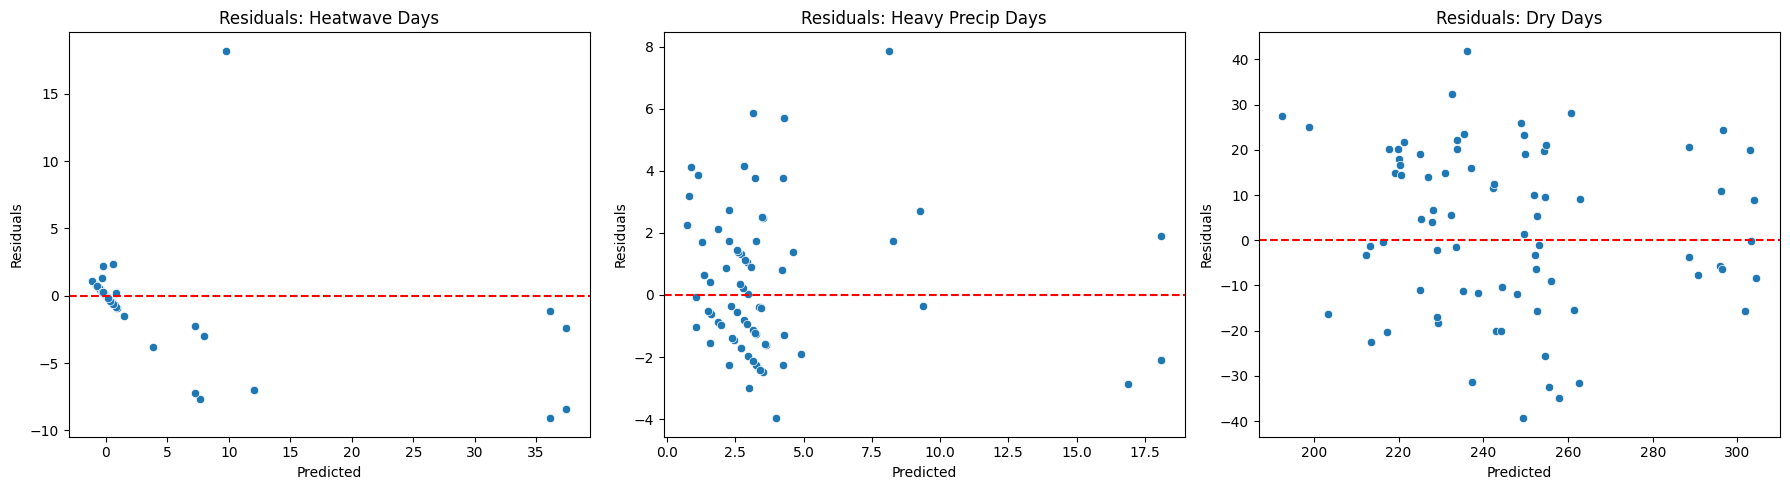

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=y_pred[:, 0], y=residuals_df["heatwave_resid"], ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals: Heatwave Days")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

sns.scatterplot(x=y_pred[:, 1], y=residuals_df["precip_resid"], ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals: Heavy Precip Days")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")

sns.scatterplot(x=y_pred[:, 2], y=residuals_df["dry_resid"], ax=axes[2])
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_title("Residuals: Dry Days")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

In [23]:
model_full = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", LinearRegression())]
)
model_full.fit(X, y)

y_pred_full = model_full.predict(X)

In [24]:
# print the model coefficients rounded to 3 decimal places
# not in scientific notation
np.set_printoptions(suppress=True)

model_full.named_steps["regressor"].coef_.round(3)

array([[ -0.833,  -0.936,  13.106,   0.054,   0.265,   2.421,   0.961,
          2.599,  42.634,   0.2  , -43.092,   4.691,   6.431, -10.612,
          4.844, -32.379,  13.799,   5.545,   1.176,   6.384, -26.677,
          5.726,   9.675,   6.371,   8.513,  -2.788, -16.122,   1.905,
         -4.751,   2.084,   5.938,   4.524],
       [  0.397,  -0.22 , -10.582,   5.162,  -0.115,  -2.793, -10.458,
         -4.885,  -7.083,  -3.834,  26.94 , -14.453,  -8.553,  11.849,
         -7.667,  20.714,  -3.723,   7.066,  -1.559,  -2.234,  28.669,
         -5.57 , -18.584,  -6.591, -18.461,  -9.909,  14.927,   2.704,
          9.845, -11.992,  13.948,   1.685],
       [ -3.824,   1.559, -33.195, -25.964,  -0.092, -17.921,  -0.423,
         -7.362,  21.505, -15.026, 116.224,   2.589, -59.617, 104.751,
        -38.606,  78.1  ,  50.54 , -60.417, -12.689, -72.664,  67.859,
        -59.7  ,   8.375, -64.982,  81.908,   8.342, -10.986,   5.597,
        -22.792,  26.211, -75.76 , -53.058]])